In [1]:
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt


In [3]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
BASE_PATH = r"D:\Amrita\Semester-2\Deep Learning\Lab Evaluations\week-4\dataset"


In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    BASE_PATH + r"\train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    BASE_PATH + r"\valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

NUM_CLASSES = len(train_ds.class_names)
class_names = train_ds.class_names
print("Classes:", NUM_CLASSES)


Found 6552 files belonging to 102 classes.
Found 818 files belonging to 102 classes.
Classes: 102


In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


In [6]:
def dataset_to_numpy(ds):
    images, labels = [], []
    for x, y in ds:
        images.append(x.numpy())
        labels.append(y.numpy())
    return np.concatenate(images), np.concatenate(labels)

X_train, y_train = dataset_to_numpy(train_ds)
X_val, y_val = dataset_to_numpy(val_ds)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)


In [7]:
lb = LabelBinarizer()
y_train_oh = lb.fit_transform(y_train)
y_val_oh = lb.transform(y_val)


In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(X_train_flat.shape[1],)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\aksha\anaconda3\envs\deep_learning\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 102)            │        26,214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,449,510 (24.60 MB)

 Trainable params: 6,449,510 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train_flat, y_train_oh,
    validation_data=(X_val_flat, y_val_oh),
    epochs=20,
    batch_size=64
)


Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.0331 - loss: 4.6503 - val_accuracy: 0.0599 - val_loss: 4.1846
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.0557 - loss: 4.1684 - val_accuracy: 0.1064 - val_loss: 4.0003
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0644 - loss: 4.0280 - val_accuracy: 0.1100 - val_loss: 3.7761
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0762 - loss: 3.9508 - val_accuracy: 0.1161 - val_loss: 3.7176
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0775 - loss: 3.8946 - val_accuracy: 0.1357 - val_loss: 3.6262
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0784 - loss: 3.8482 - val_accuracy: 0.1137 - val_loss: 3.5782
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0862 - loss: 3.8263 - val_accuracy: 0.1333 - val_loss: 3.6333
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0827 - loss: 3.8058 - val_accu

In [10]:
val_loss, val_acc = model.evaluate(X_val_flat, y_val_oh)
print("Validation Accuracy:", val_acc)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1638 - loss: 3.3952
Validation Accuracy: 0.16381418704986572


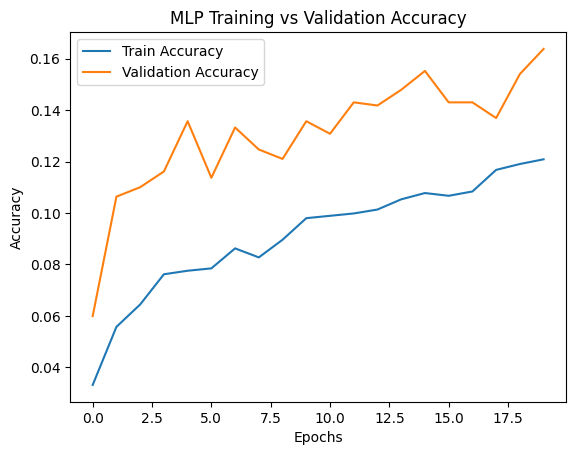

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("MLP Training vs Validation Accuracy")
plt.show()

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    BASE_PATH + r"\test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode=None,
    shuffle=False
)

test_ds = test_ds.map(lambda x: normalization_layer(x))

Found 819 files.


In [13]:
def dataset_to_numpy_images(ds):
    images = []
    for x in ds:
        images.append(x.numpy())
    return np.concatenate(images)

X_test = dataset_to_numpy_images(test_ds)
X_test_flat = X_test.reshape(X_test.shape[0], -1)


In [ ]:
pred_probs = model.predict(X_test_flat)
pred_classes = np.argmax(pred_probs, axis=1)

print("First 10 Predictions:", pred_classes[:10])


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
First 10 Predictions: [77 77 77 77 77 77 77 77 77 77]


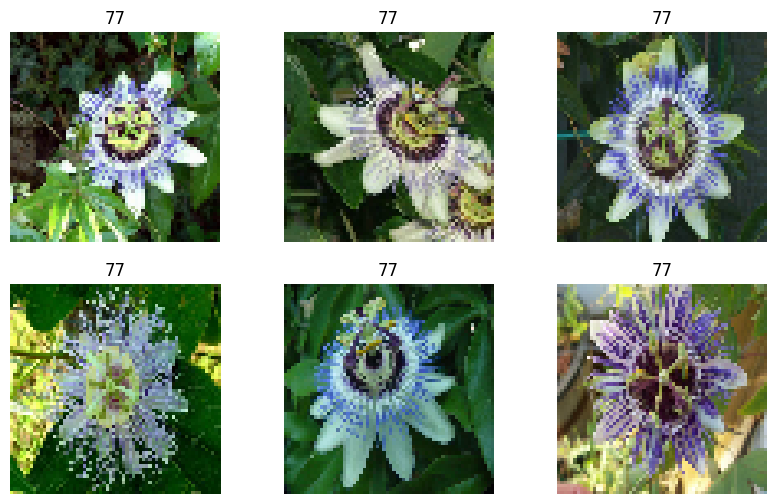

In [15]:
plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i])
    plt.title(class_names[pred_classes[i]])
    plt.axis('off')
plt.show()
